In [1]:
import json

import colorcet
import h5py
import matplotlib.pyplot as plt
import numba
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [42]:
config_id = 404
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    phase_store = store["production"]
    config = json.loads(phase_store["metadata/config_source"][()])
    config_used = json.loads(phase_store["metadata/config"][()])

    positions_history = []
    for step_key in phase_store[".steps"]:
        positions = phase_store[step_key]["positions"][:]
        positions_history.append(positions)
    positions_history = np.array(positions_history)

In [43]:
for key, value in config["meta"]["config_data"].items():
    print(f"{key:26s} {value}")

config_id                  404
chain_length               69
association_valency        5
association_rate           4880.439276667714
association_constant       11.811760240860906
association_energy         3.8068374913669034
extruder_loading_constant  0.002266126816656489


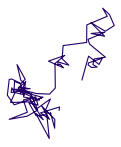

In [44]:
path = positions_history[:100, positions_history.shape[1] // 2, :]

fig, ax = plt.subplots(figsize=(0.8, 0.8))
ax.plot(path[:, 0], path[:, 1], lw=0.4, color="#206")
ax.set_aspect("equal")
set_axis(ax, "none")
pass

In [45]:
def collect_msd(path: np.ndarray, lag: int) -> np.ndarray:
    squared_dists = np.zeros((lag,) + path.shape[1:-1])
    for t in range(0, len(path) - lag):
        deltas = path[t:t + lag] - path[t]
        squared_dists += (deltas ** 2).sum(-1)
    return squared_dists / (len(path) - lag)

In [46]:
msd = collect_msd(positions_history, lag=10).mean(1)

frame_interval = config["sampling"]["timestep"] * config["sampling"]["sampling_interval"]
x = frame_interval * np.arange(len(msd))
y = msd
alpha, beta = fit_power_law(x, y)

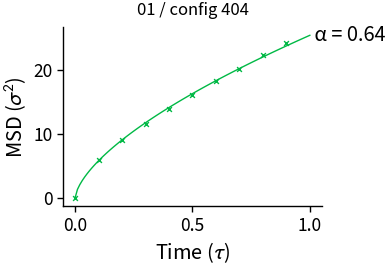

In [47]:
color = "C:g"

fig, ax = plt.subplots(figsize=(2.0, 1.4))

x = np.arange(len(msd)) * frame_interval
y = msd
ax.scatter(x, y, s=3, marker="x", color=color)

x = np.linspace(0, 1, num=100)
y = x**alpha * beta
ax.plot(x, y, color=color)

x = 1
y = beta
s = " α = %.2f" % alpha
ax.text(x, y, s, ha="left", va="center")

ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")
ax.set_title(f"01 / config {config_id}", fontsize="small")

set_axis(ax, "left bottom")

pass